# Conditional RealNVP para generar escenarios BTC–ETH

Este notebook implementa y evalúa una única configuración de Normalizing Flow condicional para nuestro dataset, siguiendo la misma estructura de los notebooks del resto del equipo.

El recorrido es:

1. cargar el mismo split temporal y la misma normalización del proyecto;
2. declarar explícitamente la arquitectura utilizada;
3. construir el Conditional RealNVP directamente en el notebook;
4. entrenar 60 épocas completas y conservar el mejor estado según validación;
5. generar múltiples trayectorias BTC–ETH para una misma condición;
6. evaluar el modelo con el `TrajectoryEvaluator` común del repositorio;
7. guardar checkpoint, métricas y escenarios de forma reproducible.

El objetivo no es predecir un único precio futuro. Queremos aprender la **distribución condicional de trayectorias futuras** de BTC y ETH durante 30 días, dado el estado de mercado observado en los 60 días anteriores.


## Relación con el baseline y decisiones metodológicas

`01_block_bootstrap_multivariante.ipynb` es el baseline no paramétrico del proyecto y `CVAE_BTC_ETH.ipynb` es el otro generador neuronal. Para que la comparación sea coherente, mantenemos las decisiones comunes:

- trayectorias conjuntas de 120 velas de seis horas, con BTC y ETH generados conjuntamente;
- condición de 14 variables construida por el pipeline común;
- entrenamiento restringido a `train`, selección del checkpoint con `validation` y evaluación final en `test`;
- retornos logarítmicos desnormalizados antes de calcular métricas financieras;
- las mismas seis familias del `TrajectoryEvaluator` común;
- control adicional con objetivos no solapados para no confundir número de ventanas con información independiente.

La particularidad del flow es que la transformación es **invertible** y permite calcular una densidad exacta bajo el modelo, además de generar escenarios.


In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
import copy
import json
import math
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from crypto_generative.evaluation import (
    CrossAssetDependenceConfig,
    DiversityMemorizationConfig,
    RiskMetricsConfig,
    TemporalDependenceConfig,
    TrajectoryEvaluator,
    TrajectoryMetricsConfig,
)

DATASET_PATH = ROOT / "data/normalized/binance/btc_eth_6h_c240_t120_train_normalized.npz"
SPLIT_PATH = ROOT / "data/splits/binance/btc_eth_6h_c240_t120_purged_split.npz"
OUTPUT_DIR = ROOT / "outputs/normalizing_flow_best"

SEED = 42
BATCH_SIZE = 256
EPOCHS = 60
SCENARIOS_PER_CONDITION = 20
DEVICE = torch.device("cpu")  # misma configuración reproducible usada en nuestros experimentos finales

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)
print("Raíz del proyecto detectada:", ROOT.name)


PyTorch: 2.13.0
Dispositivo: cpu
Raíz del proyecto detectada: Taller_Generativos


## 1. Dataset y split temporal

Cada muestra contiene:

- `condition_features`: 14 variables normalizadas que resumen los 60 días anteriores;
- `target_returns`: una matriz `(120, 2)` con los retornos de seis horas de BTC y ETH durante los siguientes 30 días.

Usamos exactamente los artefactos congelados del proyecto. La normalización fue ajustada únicamente con train y los bloques temporales están separados mediante purga.


In [2]:
with np.load(DATASET_PATH, allow_pickle=False) as data:
    conditions = data["condition_features"].astype(np.float32)
    targets = data["target_returns"].astype(np.float32)
    feature_names = data["feature_names"].copy()
    assets = data["assets"].copy()
    return_mean = data["return_mean"].astype(np.float32)
    return_scale = data["return_scale"].astype(np.float32)

with np.load(SPLIT_PATH, allow_pickle=False) as split:
    train_ids = split["train_sample_ids"].copy()
    validation_ids = split["validation_sample_ids"].copy()
    test_ids = split["test_sample_ids"].copy()

x_train, c_train = targets[train_ids], conditions[train_ids]
x_validation, c_validation = targets[validation_ids], conditions[validation_ids]
x_test, c_test = targets[test_ids], conditions[test_ids]

dataset_summary = pd.DataFrame({
    "bloque": ["train", "validación", "test"],
    "muestras": [len(x_train), len(x_validation), len(x_test)],
    "objetivo": [str(x_train.shape[1:]), str(x_validation.shape[1:]), str(x_test.shape[1:])],
    "condición": [str(c_train.shape[1:]), str(c_validation.shape[1:]), str(c_test.shape[1:])],
})
display(dataset_summary)
print("Activos:", assets.tolist())
print("Variables de condición:", len(feature_names))


,bloque,muestras,objetivo,condición
0,train,4710,"(120, 2)","(14,)"
1,validación,1832,"(120, 2)","(14,)"
2,test,1826,"(120, 2)","(14,)"


Activos: ['BTC', 'ETH']
Variables de condición: 14


Las ventanas se desplazan una vela cada vez y se solapan mucho. El número de muestras es útil para entrenar el modelo, pero no debe interpretarse como el mismo número de historias económicas independientes. Al final repetiremos métricas con anclas separadas por 120 velas.


## 2. Configuración utilizada

La ejecución usa la siguiente configuración:

- 8 capas de acoplamiento afín RealNVP;
- trayectoria aplanada de `120 × 2 = 240` dimensiones;
- condicionadores MLP con 2 capas ocultas de 256 neuronas y activación SiLU;
- límite de escala `2.0` para estabilizar el Jacobiano;
- AdamW con `learning_rate=1e-3` y `weight_decay=1e-6`;
- batch de 256;
- 60 épocas completas;
- guardado del estado con menor NLL en validación.

Entrenamos las 60 épocas para visualizar completamente la convergencia. No usamos early stopping para cortar el entrenamiento; la validación se utiliza para **seleccionar el checkpoint**, no para modificar el test.


In [3]:
@dataclass(frozen=True)
class FlowConfig:
    trajectory_length: int = 120
    n_assets: int = 2
    condition_dim: int = 14
    n_coupling_layers: int = 8
    hidden_dim: int = 256
    n_hidden_layers: int = 2
    scale_limit: float = 2.0
    learning_rate: float = 1e-3
    weight_decay: float = 1e-6
    batch_size: int = 256
    epochs: int = 60
    grad_clip_norm: float = 5.0
    seed: int = 42

    @property
    def data_dim(self):
        return self.trajectory_length * self.n_assets

CONFIG = FlowConfig()
pd.Series(asdict(CONFIG), name="valor").to_frame()


,valor
trajectory_length,120.000000
n_assets,2.000000
condition_dim,14.000000
n_coupling_layers,8.000000
hidden_dim,256.000000
n_hidden_layers,2.000000
scale_limit,2.000000
learning_rate,0.001000
weight_decay,0.000001
batch_size,256.000000


## 3. Alcance de esta ejecución

El notebook entrena únicamente la configuración declarada en la sección anterior.
La validación se usa para escoger el checkpoint con menor NLL durante sus 60
épocas y el test se reserva para la evaluación común posterior. No se atribuyen a
esta ejecución comparaciones de arquitecturas o hiperparámetros que no se calculan
dentro del notebook.


## 4. Cómo funciona el Conditional RealNVP

### 4.1 De una trayectoria compleja a una distribución sencilla

Aplanamos cada trayectoria futura:

\[
x \in \mathbb{R}^{120\times 2}\rightarrow x_{flat}\in\mathbb{R}^{240}.
\]

El flow aprende una función invertible condicionada por el estado de mercado `c`:

\[
z=f_\theta(x;c),\qquad z\sim\mathcal{N}(0,I).
\]

La dirección `x → z` sirve para calcular densidad. La inversa `z → x` sirve para generar trayectorias nuevas.

### 4.2 Capas de acoplamiento

Cada capa divide las 240 coordenadas en dos grupos. Una mitad queda fija y, junto con las 14 variables de condición, entra en un MLP que calcula `shift` y `log_scale` para transformar la otra mitad. Alternamos particiones y permutaciones entre capas para que todas las dimensiones puedan interactuar.

Como la transformación es triangular, el determinante del Jacobiano se calcula de forma eficiente y obtenemos una likelihood exacta bajo el modelo.


In [4]:
class ConditionerMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=256, n_hidden_layers=2):
        super().__init__()
        layers = []
        in_features = input_dim
        for _ in range(n_hidden_layers):
            layers += [nn.Linear(in_features, hidden_dim), nn.SiLU()]
            in_features = hidden_dim
        final = nn.Linear(in_features, output_dim)
        nn.init.zeros_(final.weight)
        nn.init.zeros_(final.bias)
        layers.append(final)
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class ConditionalAffineCoupling(nn.Module):
    def __init__(self, data_dim, condition_dim, identity_indices, transform_indices, config):
        super().__init__()
        self.scale_limit = config.scale_limit
        self.register_buffer("identity_indices", identity_indices.long())
        self.register_buffer("transform_indices", transform_indices.long())
        self.conditioner = ConditionerMLP(
            input_dim=identity_indices.numel() + condition_dim,
            output_dim=2 * transform_indices.numel(),
            hidden_dim=config.hidden_dim,
            n_hidden_layers=config.n_hidden_layers,
        )

    def _params(self, x_identity, condition):
        shift, raw_log_scale = self.conditioner(
            torch.cat([x_identity, condition], dim=-1)
        ).chunk(2, dim=-1)
        log_scale = self.scale_limit * torch.tanh(raw_log_scale / self.scale_limit)
        return shift, log_scale

    def forward(self, x, condition):
        x_identity = x.index_select(-1, self.identity_indices)
        x_transform = x.index_select(-1, self.transform_indices)
        shift, log_scale = self._params(x_identity, condition)
        y = x.clone()
        y[:, self.identity_indices] = x_identity
        y[:, self.transform_indices] = x_transform * torch.exp(log_scale) + shift
        return y, log_scale.sum(-1)

    def inverse(self, y, condition):
        y_identity = y.index_select(-1, self.identity_indices)
        y_transform = y.index_select(-1, self.transform_indices)
        shift, log_scale = self._params(y_identity, condition)
        x = y.clone()
        x[:, self.identity_indices] = y_identity
        x[:, self.transform_indices] = (y_transform - shift) * torch.exp(-log_scale)
        return x, -log_scale.sum(-1)


class FixedPermutation(nn.Module):
    def __init__(self, permutation):
        super().__init__()
        permutation = permutation.long()
        inverse = torch.empty_like(permutation)
        inverse[permutation] = torch.arange(permutation.numel())
        self.register_buffer("permutation", permutation)
        self.register_buffer("inverse_permutation", inverse)

    def forward(self, x):
        return x.index_select(-1, self.permutation)

    def inverse(self, y):
        return y.index_select(-1, self.inverse_permutation)


class ConditionalRealNVP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        generator = torch.Generator().manual_seed(config.seed)
        half = config.data_dim // 2
        transforms = []
        for layer_index in range(config.n_coupling_layers):
            permutation = torch.randperm(config.data_dim, generator=generator)
            if layer_index == 0:
                permutation = torch.arange(config.data_dim)
            identity = torch.arange(0, half)
            transform = torch.arange(half, config.data_dim)
            if layer_index % 2 == 1:
                identity, transform = transform, identity
            transforms.append(nn.ModuleDict({
                "permutation": FixedPermutation(permutation),
                "coupling": ConditionalAffineCoupling(
                    config.data_dim,
                    config.condition_dim,
                    identity,
                    transform,
                    config,
                ),
            }))
        self.transforms = nn.ModuleList(transforms)

    def transform_to_base(self, x, condition):
        z = x
        total_log_det = torch.zeros(x.shape[0], device=x.device)
        for transform in self.transforms:
            z = transform["permutation"](z)
            z, log_det = transform["coupling"](z, condition)
            total_log_det += log_det
        return z, total_log_det

    def transform_from_base(self, z, condition):
        x = z
        total_inverse_log_det = torch.zeros(z.shape[0], device=z.device)
        for transform in reversed(self.transforms):
            x, log_det = transform["coupling"].inverse(x, condition)
            x = transform["permutation"].inverse(x)
            total_inverse_log_det += log_det
        return x, total_inverse_log_det

    def log_prob(self, x, condition):
        z, log_det = self.transform_to_base(x, condition)
        base_log_prob = -0.5 * (z.square() + math.log(2 * math.pi)).sum(-1)
        return base_log_prob + log_det

    @torch.no_grad()
    def sample(self, condition, seed):
        generator = torch.Generator(device="cpu").manual_seed(seed)
        z = torch.randn(len(condition), self.config.data_dim, generator=generator)
        z = z.to(condition.device)
        paths, _ = self.transform_from_base(z, condition)
        return paths


### 4.3 NLL exacta e invertibilidad

La pérdida es la Negative Log-Likelihood:

\[
-\log p(x\mid c) = -\log p_Z(f(x;c)) - \log\left|\det J_f(x;c)\right|.
\]

No hay discriminador ni reconstrucción aproximada: el modelo maximiza directamente la likelihood condicional. Antes de entrenar comprobamos además que `forward → inverse` recupera la misma trayectoria numéricamente.


In [5]:
def flatten_paths(x):
    return torch.as_tensor(x, dtype=torch.float32).reshape(len(x), -1)


torch.manual_seed(CONFIG.seed)
model = ConditionalRealNVP(CONFIG).to(DEVICE)

x_check = flatten_paths(x_train[:8]).to(DEVICE)
c_check = torch.as_tensor(c_train[:8], dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    z_check, _ = model.transform_to_base(x_check, c_check)
    x_recovered, _ = model.transform_from_base(z_check, c_check)

max_reconstruction_error = (x_recovered - x_check).abs().max().item()
parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Parámetros entrenables:", f"{parameter_count:,}")
print("Error máximo forward→inverse:", f"{max_reconstruction_error:.3e}")


Parámetros entrenables: 1,296,256
Error máximo forward→inverse: 0.000e+00


## 5. Entrenamiento del único modelo

Entrenamos exactamente 60 épocas. En cada época:

1. barajamos train de forma reproducible;
2. minimizamos NLL por dimensión con AdamW;
3. calculamos NLL sobre validación;
4. guardamos en memoria el estado con mejor validación;
5. seguimos hasta la época 60 para observar si aparece sobreajuste.

Al terminar restauramos el mejor estado antes de generar escenarios.


In [6]:
def mean_nll_per_dimension(model, loader):
    model.eval()
    total_nll = 0.0
    total_examples = 0
    with torch.no_grad():
        for xb, cb in loader:
            xb, cb = xb.to(DEVICE), cb.to(DEVICE)
            nll = -model.log_prob(xb, cb)
            total_nll += nll.sum().item()
            total_examples += len(xb)
    return total_nll / (total_examples * CONFIG.data_dim)


x_train_flat = flatten_paths(x_train)
x_validation_flat = flatten_paths(x_validation)

train_loader = DataLoader(
    TensorDataset(x_train_flat, torch.as_tensor(c_train, dtype=torch.float32)),
    batch_size=CONFIG.batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(CONFIG.seed),
)
validation_loader = DataLoader(
    TensorDataset(x_validation_flat, torch.as_tensor(c_validation, dtype=torch.float32)),
    batch_size=CONFIG.batch_size,
    shuffle=False,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG.learning_rate,
    weight_decay=CONFIG.weight_decay,
)

train_history, validation_history = [], []
best_validation = float("inf")
best_epoch = -1
best_state = copy.deepcopy(model.state_dict())

for epoch in range(CONFIG.epochs):
    model.train()
    total_nll = 0.0
    total_examples = 0
    for xb, cb in train_loader:
        xb, cb = xb.to(DEVICE), cb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        nll = -model.log_prob(xb, cb).mean()
        loss = nll / CONFIG.data_dim
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG.grad_clip_norm)
        optimizer.step()
        total_nll += nll.item() * len(xb)
        total_examples += len(xb)

    train_nll = total_nll / (total_examples * CONFIG.data_dim)
    validation_nll = mean_nll_per_dimension(model, validation_loader)
    train_history.append(train_nll)
    validation_history.append(validation_nll)

    if validation_nll < best_validation - 1e-4:
        best_validation = validation_nll
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    if epoch == 0 or (epoch + 1) % 5 == 0 or epoch == best_epoch:
        print(
            f"epoch={epoch+1:03d} train_nll_dim={train_nll:.6f} "
            f"val_nll_dim={validation_nll:.6f}"
        )

model.load_state_dict(best_state)
print(f"\nMejor época: {best_epoch + 1}")
print(f"Mejor NLL validación/dim: {best_validation:.6f}")


epoch=001 train_nll_dim=1.224218 val_nll_dim=0.967968
epoch=002 train_nll_dim=1.110414 val_nll_dim=0.901738
epoch=003 train_nll_dim=0.997897 val_nll_dim=0.838305
epoch=004 train_nll_dim=0.894996 val_nll_dim=0.805840
epoch=005 train_nll_dim=0.831012 val_nll_dim=0.798261
epoch=010 train_nll_dim=0.687022 val_nll_dim=0.868884
epoch=015 train_nll_dim=0.583612 val_nll_dim=1.104302
epoch=020 train_nll_dim=0.493155 val_nll_dim=1.599914
epoch=025 train_nll_dim=0.421447 val_nll_dim=2.459750
epoch=030 train_nll_dim=0.354244 val_nll_dim=4.371567
epoch=035 train_nll_dim=0.297339 val_nll_dim=7.794106
epoch=040 train_nll_dim=0.258358 val_nll_dim=9.813039
epoch=045 train_nll_dim=0.216477 val_nll_dim=13.618676
epoch=050 train_nll_dim=0.184957 val_nll_dim=17.555604
epoch=055 train_nll_dim=0.153419 val_nll_dim=21.625080
epoch=060 train_nll_dim=0.122308 val_nll_dim=28.838729

Mejor época: 5
Mejor NLL validación/dim: 0.798261


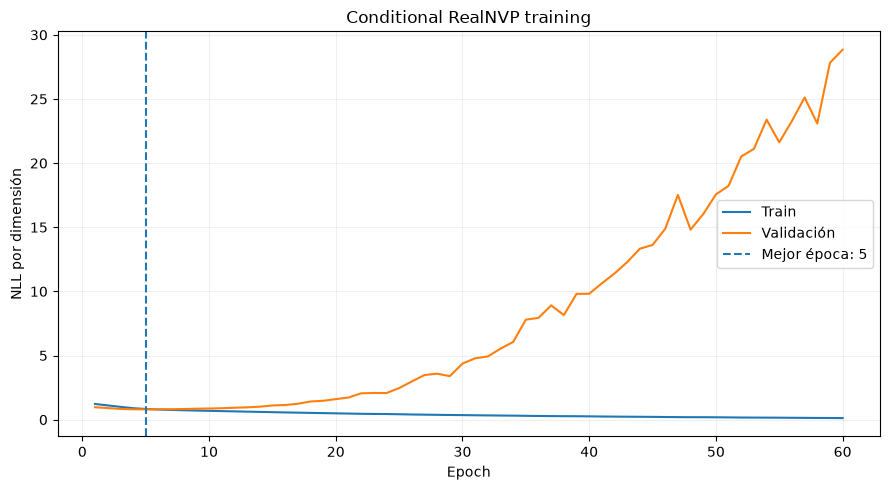

In [7]:
epochs = np.arange(1, CONFIG.epochs + 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, train_history, label="Train")
ax.plot(epochs, validation_history, label="Validación")
ax.axvline(best_epoch + 1, linestyle="--", label=f"Mejor época: {best_epoch + 1}")
ax.set(title="Conditional RealNVP training", xlabel="Epoch", ylabel="NLL por dimensión")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


La curva completa permite distinguir **optimización** de **generalización**: aunque la NLL de train puede seguir bajando, el checkpoint final es el que minimiza la NLL de validación. El test permanece intacto hasta la sección de evaluación común.


## 6. Generación de escenarios

Para una condición fija muestreamos distintos `z ~ N(0, I)` y aplicamos la transformación inversa. Así obtenemos múltiples futuros compatibles con el mismo estado de mercado.


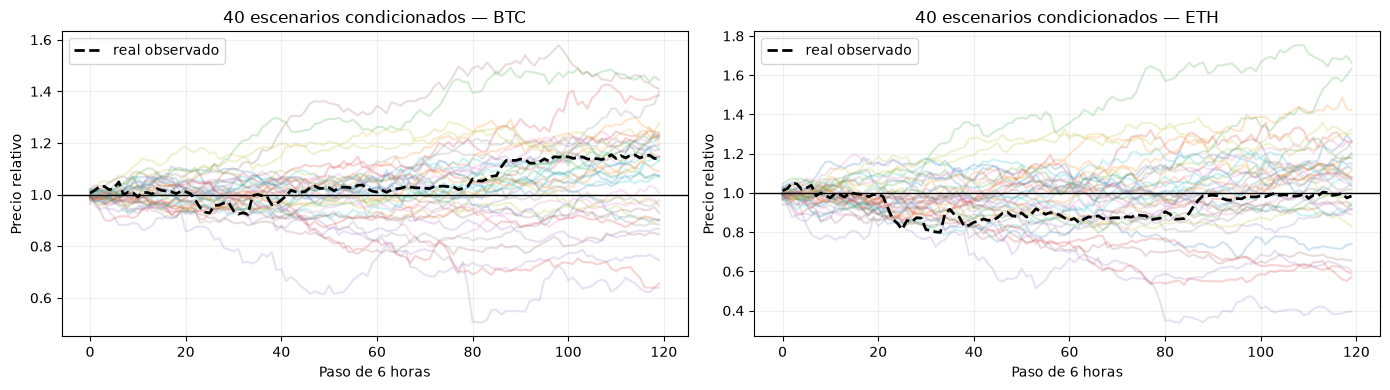

In [8]:
def sample_flow(model, conditions, seed):
    conditions_tensor = torch.as_tensor(conditions, dtype=torch.float32, device=DEVICE)
    model.eval()
    with torch.no_grad():
        generated_flat = model.sample(conditions_tensor, seed=seed)
    return generated_flat.cpu().numpy().reshape(-1, CONFIG.trajectory_length, CONFIG.n_assets)


example_condition = np.repeat(c_test[:1], 40, axis=0)
example_generated_normalized = sample_flow(model, example_condition, seed=20_260_807)
example_returns = example_generated_normalized * return_scale[None, None, :] + return_mean[None, None, :]
real_example_returns = x_test[0] * return_scale[None, :] + return_mean[None, :]

generated_prices = np.exp(np.cumsum(example_returns, axis=1))
real_price = np.exp(np.cumsum(real_example_returns, axis=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for asset_index, (axis, asset) in enumerate(zip(axes, assets)):
    axis.plot(generated_prices[:, :, asset_index].T, alpha=0.2)
    axis.plot(real_price[:, asset_index], "k--", linewidth=2, label="real observado")
    axis.axhline(1.0, color="black", linewidth=1)
    axis.set_title(f"40 escenarios condicionados — {asset}")
    axis.set_xlabel("Paso de 6 horas")
    axis.set_ylabel("Precio relativo")
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()


## 7. Evaluación común en test

Una vez fijada la arquitectura y restaurado el mejor checkpoint de validación, evaluamos en el bloque de test congelado.

Para seguir el mismo protocolo que el CVAE generamos `20` escenarios por cada condición de test. Las métricas marginales, temporales, cruzadas, de trayectoria y diversidad usan todas esas trayectorias. Para riesgo conservamos la dimensión condicional `[condición, draws, tiempo, activo]`.


In [9]:
test_conditions_flat = np.repeat(c_test, SCENARIOS_PER_CONDITION, axis=0)
generated_normalized_flat = sample_flow(model, test_conditions_flat, seed=20_260_805)
generated_conditional_normalized = generated_normalized_flat.reshape(
    len(x_test), SCENARIOS_PER_CONDITION, *x_test.shape[1:]
)

reference_returns = (
    x_test * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float64)
training_returns = (
    x_train * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float64)
generated_conditional_returns = (
    generated_conditional_normalized * return_scale[None, None, None, :]
    + return_mean[None, None, None, :]
).astype(np.float64)
generated_returns = generated_conditional_returns.reshape(
    -1, generated_conditional_returns.shape[-2], generated_conditional_returns.shape[-1]
)

evaluator = TrajectoryEvaluator(assets=assets.tolist())
print("Referencia test:", reference_returns.shape)
print("Candidato condicional:", generated_conditional_returns.shape)
print("Candidato aplanado:", generated_returns.shape)


Referencia test: (1826, 120, 2)
Candidato condicional: (1826, 20, 120, 2)
Candidato aplanado: (36520, 120, 2)


### 7.1 Marginales


In [10]:
marginal_report = evaluator.evaluate_marginals(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
)
marginal_table = pd.DataFrame(marginal_report.to_records())
display(marginal_table[[
    "asset",
    "reference_standard_deviation",
    "candidate_standard_deviation",
    "reference_excess_kurtosis",
    "candidate_excess_kurtosis",
    "reference_extreme_frequency",
    "candidate_extreme_frequency",
    "normalized_wasserstein_1",
]])


,asset,reference_standard_deviation,candidate_standard_deviation,reference_excess_kurtosis,candidate_excess_kurtosis,reference_extreme_frequency,candidate_extreme_frequency,normalized_wasserstein_1
0,BTC,0.010913,0.012583,4.823215,1.238561,0.010054,0.004369,0.250393
1,ETH,0.017073,0.017147,4.760664,1.171810,0.010268,0.002378,0.155897


### 7.2 Dependencia temporal y BTC–ETH


In [11]:
temporal_report = evaluator.evaluate_temporal_dependence(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    config=TemporalDependenceConfig(
        max_lag=20,
        volatility_window=20,
        high_volatility_quantile=0.90,
        extreme_quantile=0.99,
        extreme_clustering_window=4,
    ),
)
temporal_table = pd.DataFrame(temporal_report.to_records())
display(temporal_table[[
    "asset",
    "return_acf_rmse",
    "absolute_return_acf_rmse",
    "squared_return_acf_rmse",
    "volatility_persistence_absolute_error",
    "extreme_clustering_ratio_absolute_error",
]])

cross_asset_report = evaluator.evaluate_cross_asset_dependence(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    config=CrossAssetDependenceConfig(
        rolling_window=20,
        stress_quantile=0.90,
        joint_drop_quantile=0.05,
        lower_tail_quantile=0.05,
    ),
)
cross_asset_table = pd.DataFrame(cross_asset_report.to_records())
display(cross_asset_table[[
    "asset_pair",
    "reference_contemporaneous_correlation",
    "candidate_contemporaneous_correlation",
    "contemporaneous_correlation_absolute_error",
    "rolling_correlation_wasserstein_1",
    "stress_correlation_absolute_error",
    "joint_drop_probability_absolute_error",
    "lower_tail_dependence_absolute_error",
]].T)


,asset,return_acf_rmse,absolute_return_acf_rmse,squared_return_acf_rmse,volatility_persistence_absolute_error,extreme_clustering_ratio_absolute_error
0,BTC,0.027508,0.048591,0.057891,0.261222,1.713460
1,ETH,0.035725,0.049549,0.048512,0.003946,4.562553


,0
asset_pair,BTC-ETH
reference_contemporaneous_correlation,0.846945
candidate_contemporaneous_correlation,0.756371
contemporaneous_correlation_absolute_error,0.090575
rolling_correlation_wasserstein_1,0.086606
stress_correlation_absolute_error,0.114893
joint_drop_probability_absolute_error,0.002692
lower_tail_dependence_absolute_error,0.246522


### 7.3 Trayectorias, riesgo y diversidad


In [12]:
trajectory_report = evaluator.evaluate_trajectories(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    config=TrajectoryMetricsConfig(periods_per_year=4 * 365),
)
trajectory_table = pd.DataFrame(trajectory_report.to_records())
display(trajectory_table.pivot(
    index="metric", columns="asset", values="normalized_wasserstein_1"
).rename_axis(columns=None))

risk_report = evaluator.evaluate_risk(
    reference_paths=reference_returns,
    candidate_paths=generated_conditional_returns,
    config=RiskMetricsConfig(
        confidence_levels=(0.95, 0.99),
        portfolio_weights=(0.60, 0.40),
        portfolio_name="portfolio_60_40",
        es_stability_repetitions=100,
        es_stability_sample_size=1_000,
        random_state=SEED,
    ),
)
risk_table = pd.DataFrame(risk_report.to_records())
display(risk_table[[
    "target",
    "confidence_level",
    "unconditional_var_absolute_error",
    "unconditional_es_absolute_error",
    "exception_rate",
    "expected_exception_rate",
    "coverage_absolute_error",
]])

diversity_report = evaluator.evaluate_diversity_and_memorization(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    training_paths=training_returns,
    config=DiversityMemorizationConfig(
        max_paths_per_set=2_000,
        projection_dimensions=24,
        neighbor_candidates=8,
        near_memorization_quantile=0.01,
        coverage_radius_quantile=0.95,
        discriminator_repetitions=5,
        random_state=SEED,
    ),
)
diversity_table = pd.DataFrame(diversity_report.to_records())
display(diversity_table[[
    "candidate_unique_fraction",
    "candidate_near_duplicate_fraction",
    "exact_training_match_fraction",
    "near_memorization_fraction",
    "reference_coverage_fraction",
    "regime_total_variation_distance",
    "discriminator_accuracy_mean",
]].T.rename(columns={0: "valor"}))


,BTC,ETH
metric,,
final_cumulative_return,0.514651,0.151769
intrahorizon_maximum_return,0.824694,0.170756
intrahorizon_minimum_return,0.164251,0.117124
maximum_drawdown,0.217622,0.105668
maximum_drawdown_duration_steps,0.217651,0.075279
realized_volatility,0.636170,0.140722
time_to_minimum_value_steps,0.126820,0.079142


,target,confidence_level,unconditional_var_absolute_error,unconditional_es_absolute_error,exception_rate,expected_exception_rate,coverage_absolute_error
0,BTC,0.95,0.051476,0.021004,0.180175,0.05,0.130175
1,BTC,0.99,0.004844,0.032319,0.131982,0.01,0.121982
2,ETH,0.95,0.052447,0.024526,0.167032,0.05,0.117032
3,ETH,0.99,0.005933,0.034825,0.119387,0.01,0.109387
4,portfolio_60_40,0.95,0.067712,0.036925,0.176342,0.05,0.126342
5,portfolio_60_40,0.99,0.023416,0.018548,0.134173,0.01,0.124173


,valor
candidate_unique_fraction,1.000000
candidate_near_duplicate_fraction,0.000000
exact_training_match_fraction,0.000000
near_memorization_fraction,0.001500
reference_coverage_fraction,0.932092
regime_total_variation_distance,0.259484
discriminator_accuracy_mean,0.978102


### 7.4 Diagnósticos visuales comparables con el resto de modelos

Los gráficos siguientes usan las mismas unidades y separan tres preguntas: ¿se parecen los retornos marginales?, ¿se conserva la dependencia BTC–ETH? y ¿se mantienen las propiedades de trayectoria y riesgo?


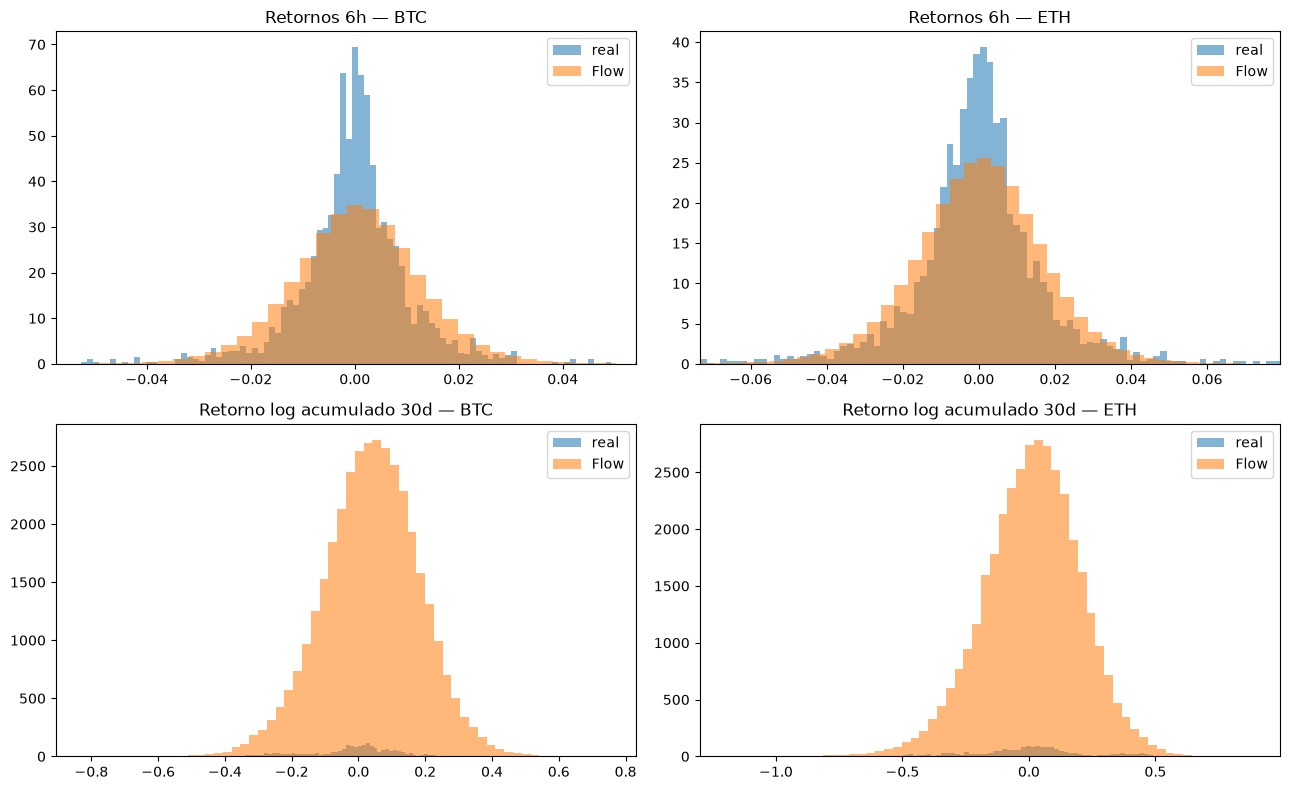

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for asset_index, asset in enumerate(assets):
    axes[0, asset_index].hist(reference_returns[:, :, asset_index].ravel(), bins=120, density=True, alpha=0.55, label="real")
    axes[0, asset_index].hist(generated_returns[:, :, asset_index].ravel(), bins=120, density=True, alpha=0.55, label="Flow")
    axes[0, asset_index].set_title(f"Retornos 6h — {asset}")
    axes[0, asset_index].set_xlim(
        np.quantile(reference_returns[:, :, asset_index], 0.001),
        np.quantile(reference_returns[:, :, asset_index], 0.999),
    )
    axes[0, asset_index].legend()
    axes[1, asset_index].hist(reference_returns[:, :, asset_index].sum(1), bins=60, alpha=0.55, label="real")
    axes[1, asset_index].hist(generated_returns[:, :, asset_index].sum(1), bins=60, alpha=0.55, label="Flow")
    axes[1, asset_index].set_title(f"Retorno log acumulado 30d — {asset}")
    axes[1, asset_index].legend()
plt.tight_layout()
plt.show()


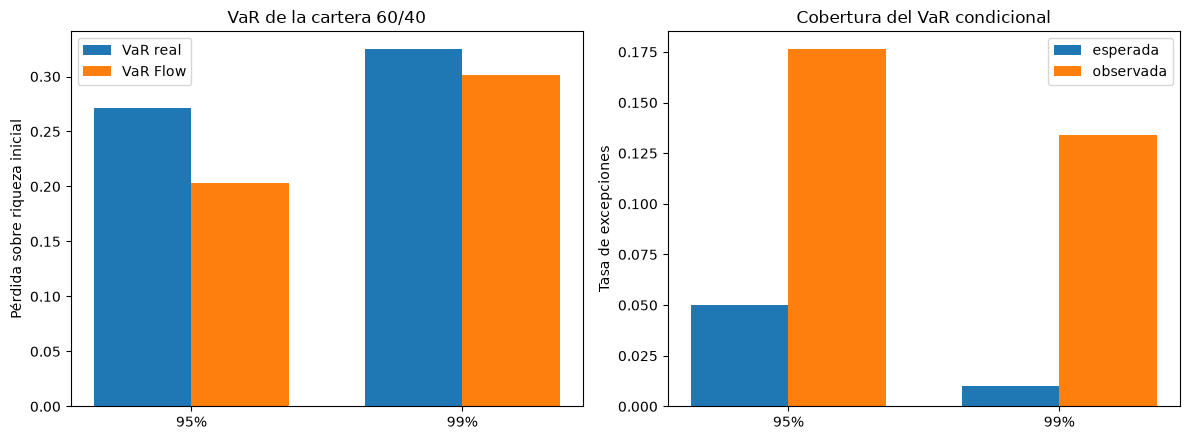

In [14]:
portfolio_risk = risk_table.loc[risk_table["target"].eq("portfolio_60_40")]
risk_positions = np.arange(len(portfolio_risk))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(risk_positions - 0.18, portfolio_risk["reference_unconditional_var"], 0.36, label="VaR real")
axes[0].bar(risk_positions + 0.18, portfolio_risk["candidate_unconditional_var"], 0.36, label="VaR Flow")
axes[0].set_xticks(risk_positions, [f"{level:.0%}" for level in portfolio_risk["confidence_level"]])
axes[0].set(title="VaR de la cartera 60/40", ylabel="Pérdida sobre riqueza inicial")
axes[0].legend()

axes[1].bar(risk_positions - 0.18, portfolio_risk["expected_exception_rate"], 0.36, label="esperada")
axes[1].bar(risk_positions + 0.18, portfolio_risk["exception_rate"], 0.36, label="observada")
axes[1].set_xticks(risk_positions, [f"{level:.0%}" for level in portfolio_risk["confidence_level"]])
axes[1].set(title="Cobertura del VaR condicional", ylabel="Tasa de excepciones")
axes[1].legend()

plt.tight_layout()
plt.show()


### 7.5 Ventaja específica del Flow: densidad exacta

Además de generar, el RealNVP puede asignar una densidad condicional a una trayectoria. Esto permite comparar la plausibilidad **bajo el modelo** de un escenario observado o prefijado. No debe interpretarse como la probabilidad verdadera del mercado.


In [15]:
def log_prob_per_dimension(model, x, condition):
    x_tensor = flatten_paths(x).to(DEVICE)
    c_tensor = torch.as_tensor(condition, dtype=torch.float32, device=DEVICE)
    model.eval()
    with torch.no_grad():
        return (model.log_prob(x_tensor, c_tensor) / CONFIG.data_dim).cpu().numpy()

real_test_logp = log_prob_per_dimension(model, x_test, c_test)

# Shock deliberadamente extremo: -30 % BTC y -40 % ETH concentrados en la primera vela.
stress = np.zeros((1, CONFIG.trajectory_length, CONFIG.n_assets), dtype=np.float32)
stress[0, 0, 0] = np.log(0.70)
stress[0, 0, 1] = np.log(0.60)
stress_normalized = (stress - return_mean[None, None, :]) / return_scale[None, None, :]
stress_logp = log_prob_per_dimension(model, stress_normalized, c_test[:1])[0]
percentile = 100 * np.mean(real_test_logp <= stress_logp)

print(f"Log-density/dim media de test real: {real_test_logp.mean():.4f}")
print(f"Log-density/dim del shock prefijado: {stress_logp:.4f}")
print(f"Percentil de densidad del shock frente a test real: {percentile:.2f}%")


Log-density/dim media de test real: -0.6890
Log-density/dim del shock prefijado: -1.7975
Percentil de densidad del shock frente a test real: 0.00%


### 7.6 Control con objetivos no solapados

Como las ventanas del dataset se solapan, repetimos una parte de la evaluación usando una ancla cada 120 velas. Quedan pocas observaciones, por lo que es un control de sensibilidad y no una estimación precisa de colas.


In [16]:
non_overlapping_ids = np.arange(0, len(x_test), 120)
non_overlapping_conditions_flat = np.repeat(
    c_test[non_overlapping_ids], SCENARIOS_PER_CONDITION, axis=0
)
non_overlapping_generated_normalized = sample_flow(
    model, non_overlapping_conditions_flat, seed=20_260_806
)
non_overlapping_reference = reference_returns[non_overlapping_ids]
non_overlapping_generated_returns = (
    non_overlapping_generated_normalized * return_scale[None, None, :]
    + return_mean[None, None, :]
).astype(np.float64)

non_overlapping_marginal_report = evaluator.evaluate_marginals(
    reference_paths=non_overlapping_reference,
    candidate_paths=non_overlapping_generated_returns,
)
non_overlapping_trajectory_report = evaluator.evaluate_trajectories(
    reference_paths=non_overlapping_reference,
    candidate_paths=non_overlapping_generated_returns,
    config=TrajectoryMetricsConfig(periods_per_year=4 * 365),
)
print("Anclas no solapadas:", len(non_overlapping_ids))
display(pd.DataFrame(non_overlapping_marginal_report.to_records())[[
    "asset", "normalized_wasserstein_1"
]].rename(columns={"normalized_wasserstein_1": "W1 marginal normalizada"}))
display(pd.DataFrame(non_overlapping_trajectory_report.to_records()).pivot(
    index="metric", columns="asset", values="normalized_wasserstein_1"
).rename_axis(columns=None))


Anclas no solapadas: 16


,asset,W1 marginal normalizada
0,BTC,0.228286
1,ETH,0.144205


,BTC,ETH
metric,,
final_cumulative_return,0.497471,0.124926
intrahorizon_maximum_return,0.789812,0.131799
intrahorizon_minimum_return,0.288290,0.120261
maximum_drawdown,0.246946,0.086394
maximum_drawdown_duration_steps,0.247702,0.223305
realized_volatility,0.592347,0.242764
time_to_minimum_value_steps,0.156896,0.176602


## 8. Impacto de la augmentación sintética en un modelo downstream

El objetivo del taller no es solo comprobar si el generador produce trayectorias plausibles, sino también medir si **usar datos sintéticos cambia el rendimiento de un segundo modelo**.

Definimos una tarea financiera sencilla y común a todas las mezclas:

- **Entrada:** las 14 variables de condición que resumen el estado previo del mercado.
- **Objetivo:** predecir la magnitud del **máximo drawdown a 30 días** de una cartera 60 % BTC / 40 % ETH.
- **Modelo downstream:** el mismo MLP en todos los experimentos.
- **Validación y test:** siempre reales y sin cambios.
- **Única diferencia entre experimentos:** el número de trayectorias sintéticas añadidas al train.

Las mezclas son `0 %`, `+25 %`, `+50 %` y `+100 %`, donde el porcentaje indica **datos sintéticos adicionales respecto al tamaño del train real**. Por ejemplo, `+100 %` significa 4.710 observaciones reales + 4.710 sintéticas.

Para evitar leakage, las trayectorias sintéticas de esta sección se generan **solo condicionando con estados del bloque de entrenamiento**. Los bloques de validación y test no se usan para construir ningún ejemplo sintético de train.

In [17]:
# Generamos una trayectoria sintética por cada condición de train.
# El orden aleatorio se fija una sola vez; así, los datasets +25 %, +50 % y +100 %
# son subconjuntos anidados del mismo conjunto sintético maestro.

DOWNSTREAM_SEED = 2026
AUGMENTATION_RATIOS = (0.00, 0.25, 0.50, 1.00)
GENERATION_BATCH_SIZE = 256

rng = np.random.default_rng(DOWNSTREAM_SEED)
synthetic_order = rng.permutation(len(c_train))
synthetic_train_conditions = c_train[synthetic_order]

synthetic_chunks = []
for batch_index, start in enumerate(range(0, len(synthetic_train_conditions), GENERATION_BATCH_SIZE)):
    stop = min(start + GENERATION_BATCH_SIZE, len(synthetic_train_conditions))
    chunk = sample_flow(
        model,
        synthetic_train_conditions[start:stop],
        seed=DOWNSTREAM_SEED + 10_000 + batch_index,
    )
    synthetic_chunks.append(chunk)
    print(f"Generadas {stop:4d}/{len(synthetic_train_conditions)} trayectorias sintéticas de train")

synthetic_train_normalized = np.concatenate(synthetic_chunks, axis=0)
synthetic_train_returns = (
    synthetic_train_normalized * return_scale[None, None, :]
    + return_mean[None, None, :]
).astype(np.float32)

augmentation_manifest = []
for ratio in AUGMENTATION_RATIOS:
    synthetic_count = int(round(len(x_train) * ratio))
    augmentation_manifest.append({
        "dataset": "real_only" if ratio == 0 else f"real_plus_{int(ratio*100)}pct_flow",
        "real_samples": len(x_train),
        "synthetic_samples": synthetic_count,
        "total_samples": len(x_train) + synthetic_count,
        "synthetic_addition_vs_real": ratio,
        "synthetic_share_of_total": synthetic_count / (len(x_train) + synthetic_count),
    })

augmentation_manifest = pd.DataFrame(augmentation_manifest)
display(augmentation_manifest)

Generadas  256/4710 trayectorias sintéticas de train
Generadas  512/4710 trayectorias sintéticas de train
Generadas  768/4710 trayectorias sintéticas de train
Generadas 1024/4710 trayectorias sintéticas de train
Generadas 1280/4710 trayectorias sintéticas de train
Generadas 1536/4710 trayectorias sintéticas de train
Generadas 1792/4710 trayectorias sintéticas de train
Generadas 2048/4710 trayectorias sintéticas de train
Generadas 2304/4710 trayectorias sintéticas de train
Generadas 2560/4710 trayectorias sintéticas de train
Generadas 2816/4710 trayectorias sintéticas de train
Generadas 3072/4710 trayectorias sintéticas de train
Generadas 3328/4710 trayectorias sintéticas de train
Generadas 3584/4710 trayectorias sintéticas de train
Generadas 3840/4710 trayectorias sintéticas de train
Generadas 4096/4710 trayectorias sintéticas de train
Generadas 4352/4710 trayectorias sintéticas de train
Generadas 4608/4710 trayectorias sintéticas de train
Generadas 4710/4710 trayectorias sintéticas de

,dataset,real_samples,synthetic_samples,total_samples,synthetic_addition_vs_real,synthetic_share_of_total
0,real_only,4710,0,4710,0.00,0.000000
1,real_plus_25pct_flow,4710,1178,5888,0.25,0.200068
2,real_plus_50pct_flow,4710,2355,7065,0.50,0.333333
3,real_plus_100pct_flow,4710,4710,9420,1.00,0.500000


In [18]:
@dataclass(frozen=True)
class DownstreamConfig:
    hidden_dim_1: int = 64
    hidden_dim_2: int = 32
    dropout: float = 0.10
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 128
    epochs: int = 100
    patience: int = 15
    seed: int = 2026


class DrawdownMLP(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, config.hidden_dim_1),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim_1, config.hidden_dim_2),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim_2, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


def maximum_drawdown_magnitude(log_return_paths, btc_weight=0.60, eth_weight=0.40):
    paths = np.asarray(log_return_paths, dtype=np.float64)
    cumulative = np.cumsum(paths, axis=1)
    gross = np.exp(cumulative)
    portfolio = btc_weight * gross[:, :, 0] + eth_weight * gross[:, :, 1]
    portfolio = np.concatenate([np.ones((len(paths), 1)), portfolio], axis=1)
    running_peak = np.maximum.accumulate(portfolio, axis=1)
    drawdown = portfolio / running_peak - 1.0
    return (-drawdown.min(axis=1)).astype(np.float32)


def set_downstream_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def downstream_loader(x, y, *, batch_size, shuffle, seed):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        TensorDataset(
            torch.as_tensor(x, dtype=torch.float32),
            torch.as_tensor(y, dtype=torch.float32),
        ),
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0,
    )


def mean_mse(model, loader):
    model.eval()
    total, count = 0.0, 0
    criterion = nn.MSELoss()
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = criterion(model(xb), yb)
            total += loss.item() * len(xb)
            count += len(xb)
    return total / count


def train_downstream(train_x, train_y, validation_x, validation_y, target_mean, target_std, config):
    # Reiniciamos la semilla: todos los datasets parten exactamente de los mismos pesos.
    set_downstream_seed(config.seed)
    downstream_model = DrawdownMLP(train_x.shape[1], config).to(DEVICE)

    train_y_scaled = (train_y - target_mean) / target_std
    validation_y_scaled = (validation_y - target_mean) / target_std

    train_loader_ds = downstream_loader(
        train_x, train_y_scaled,
        batch_size=config.batch_size, shuffle=True, seed=config.seed,
    )
    validation_loader_ds = downstream_loader(
        validation_x, validation_y_scaled,
        batch_size=config.batch_size, shuffle=False, seed=config.seed,
    )

    criterion = nn.MSELoss()
    optimizer_ds = torch.optim.AdamW(
        downstream_model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_ds, mode="min", factor=0.5, patience=5, min_lr=1e-5
    )

    best_state_ds = None
    best_validation_ds = math.inf
    best_epoch_ds = 0
    epochs_without_improvement = 0
    history_ds = []

    for epoch in range(1, config.epochs + 1):
        downstream_model.train()
        total, count = 0.0, 0
        for xb, yb in train_loader_ds:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer_ds.zero_grad(set_to_none=True)
            loss = criterion(downstream_model(xb), yb)
            loss.backward()
            optimizer_ds.step()
            total += loss.item() * len(xb)
            count += len(xb)

        train_loss = total / count
        validation_loss = mean_mse(downstream_model, validation_loader_ds)
        scheduler.step(validation_loss)

        history_ds.append({
            "epoch": epoch,
            "train_mse_scaled": train_loss,
            "validation_mse_scaled": validation_loss,
        })

        if validation_loss < best_validation_ds - 1e-8:
            best_validation_ds = validation_loss
            best_epoch_ds = epoch
            best_state_ds = copy.deepcopy(downstream_model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= config.patience:
            break

    downstream_model.load_state_dict(best_state_ds)
    return downstream_model, pd.DataFrame(history_ds), best_epoch_ds, best_validation_ds


def downstream_predict(model, x, target_mean, target_std, batch_size=128):
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            xb = torch.as_tensor(x[start:start+batch_size], dtype=torch.float32, device=DEVICE)
            scaled = model(xb).cpu().numpy()
            predictions.append(scaled * target_std + target_mean)
    return np.concatenate(predictions)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    residual = y_pred - y_true
    mae = np.mean(np.abs(residual))
    rmse = np.sqrt(np.mean(residual**2))
    denominator = np.sum((y_true - y_true.mean())**2)
    r2 = 1.0 - np.sum(residual**2) / denominator

    threshold_90 = np.quantile(y_true, 0.90)
    tail_mae_90 = np.mean(np.abs(residual[y_true >= threshold_90]))
    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "tail_mae_worst_10pct": float(tail_mae_90),
    }


DOWNSTREAM_CONFIG = DownstreamConfig()
pd.Series(asdict(DOWNSTREAM_CONFIG), name="valor").to_frame()

,valor
hidden_dim_1,64.0000
hidden_dim_2,32.0000
dropout,0.1000
learning_rate,0.0010
weight_decay,0.0001
batch_size,128.0000
epochs,100.0000
patience,15.0000
seed,2026.0000


In [19]:
# Targets reales en escala original.
train_real_returns = (
    x_train * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float32)
validation_real_returns = (
    x_validation * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float32)
test_real_returns = (
    x_test * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float32)

train_real_y = maximum_drawdown_magnitude(train_real_returns)
synthetic_train_y = maximum_drawdown_magnitude(synthetic_train_returns)
validation_y = maximum_drawdown_magnitude(validation_real_returns)
test_y = maximum_drawdown_magnitude(test_real_returns)

# El escalado del target se fija UNA SOLA VEZ usando únicamente el train real.
target_mean = float(train_real_y.mean())
target_std = float(train_real_y.std(ddof=0))

print(f"Target train real: mean={target_mean:.6f}, std={target_std:.6f}")
print(f"Validación real: {len(validation_y)} | Test real: {len(test_y)}")

downstream_rows = []
downstream_histories = {}

for ratio_index, ratio in enumerate(AUGMENTATION_RATIOS):
    synthetic_count = int(round(len(c_train) * ratio))

    train_x_ds = np.concatenate(
        [c_train, synthetic_train_conditions[:synthetic_count]], axis=0
    ).astype(np.float32)
    train_y_ds = np.concatenate(
        [train_real_y, synthetic_train_y[:synthetic_count]], axis=0
    ).astype(np.float32)

    # Mismo barajado determinista que en nuestro pipeline original.
    dataset_seed = DOWNSTREAM_SEED if ratio == 0 else DOWNSTREAM_SEED + ratio_index
    order = np.random.default_rng(dataset_seed).permutation(len(train_x_ds))
    train_x_ds = train_x_ds[order]
    train_y_ds = train_y_ds[order]

    label = "real_only" if ratio == 0 else f"real_plus_{int(ratio*100)}pct_flow"
    print(f"\nEntrenando {label}: real={len(c_train)}, sintético={synthetic_count}, total={len(train_x_ds)}")

    downstream_model, history_ds, best_epoch_ds, best_val_ds = train_downstream(
        train_x_ds,
        train_y_ds,
        c_validation,
        validation_y,
        target_mean,
        target_std,
        DOWNSTREAM_CONFIG,
    )

    validation_pred = downstream_predict(
        downstream_model, c_validation, target_mean, target_std, DOWNSTREAM_CONFIG.batch_size
    )
    test_pred = downstream_predict(
        downstream_model, c_test, target_mean, target_std, DOWNSTREAM_CONFIG.batch_size
    )

    validation_metrics = regression_metrics(validation_y, validation_pred)
    test_metrics = regression_metrics(test_y, test_pred)

    downstream_histories[label] = history_ds
    downstream_rows.append({
        "dataset": label,
        "real_train": len(c_train),
        "synthetic_train": synthetic_count,
        "total_train": len(train_x_ds),
        "best_epoch": best_epoch_ds,
        "validation_mae": validation_metrics["mae"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "test_r2": test_metrics["r2"],
        "test_tail_mae_worst_10pct": test_metrics["tail_mae_worst_10pct"],
    })

    print(
        f"best_epoch={best_epoch_ds} | "
        f"val_MAE={validation_metrics['mae']:.4%} | "
        f"test_MAE={test_metrics['mae']:.4%} | "
        f"tail_MAE={test_metrics['tail_mae_worst_10pct']:.4%}"
    )

downstream_comparison = pd.DataFrame(downstream_rows)

display(
    downstream_comparison.assign(
        validation_mae=lambda d: 100 * d["validation_mae"],
        test_mae=lambda d: 100 * d["test_mae"],
        test_rmse=lambda d: 100 * d["test_rmse"],
        test_tail_mae_worst_10pct=lambda d: 100 * d["test_tail_mae_worst_10pct"],
    ).rename(columns={
        "validation_mae": "validation_MAE_%",
        "test_mae": "test_MAE_%",
        "test_rmse": "test_RMSE_%",
        "test_tail_mae_worst_10pct": "test_tail_MAE_%",
    })
)

baseline_mae = downstream_comparison.loc[
    downstream_comparison["dataset"].eq("real_only"), "test_mae"
].iloc[0]
best_row = downstream_comparison.loc[downstream_comparison["test_mae"].idxmin()]
relative_improvement = 100 * (baseline_mae - best_row["test_mae"]) / baseline_mae

print(
    f"\nMejor MAE test: {best_row['dataset']} = {best_row['test_mae']:.4%} "
    f"({relative_improvement:.2f}% de mejora relativa frente a real_only)"
)

Target train real: mean=0.174663, std=0.095150
Validación real: 1832 | Test real: 1826

Entrenando real_only: real=4710, sintético=0, total=4710
best_epoch=2 | val_MAE=4.7516% | test_MAE=7.9550% | tail_MAE=21.9275%

Entrenando real_plus_25pct_flow: real=4710, sintético=1178, total=5888
best_epoch=2 | val_MAE=4.8884% | test_MAE=7.8984% | tail_MAE=21.6887%

Entrenando real_plus_50pct_flow: real=4710, sintético=2355, total=7065
best_epoch=2 | val_MAE=5.1152% | test_MAE=7.8701% | tail_MAE=21.1522%

Entrenando real_plus_100pct_flow: real=4710, sintético=4710, total=9420
best_epoch=3 | val_MAE=5.0033% | test_MAE=7.6113% | tail_MAE=21.6287%


,dataset,real_train,synthetic_train,total_train,best_epoch,validation_MAE_%,test_MAE_%,test_RMSE_%,test_r2,test_tail_MAE_%
0,real_only,4710,0,4710,2,4.751624,7.955042,10.070963,-0.467465,21.927493
1,real_plus_25pct_flow,4710,1178,5888,2,4.888368,7.898364,9.985134,-0.442559,21.688667
2,real_plus_50pct_flow,4710,2355,7065,2,5.115194,7.870138,9.805104,-0.391010,21.152228
3,real_plus_100pct_flow,4710,4710,9420,3,5.003260,7.611296,9.743712,-0.373645,21.628677



Mejor MAE test: real_plus_100pct_flow = 7.6113% (4.32% de mejora relativa frente a real_only)


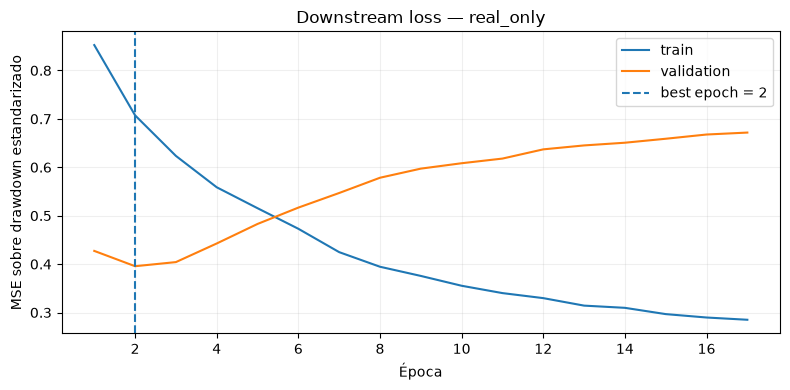

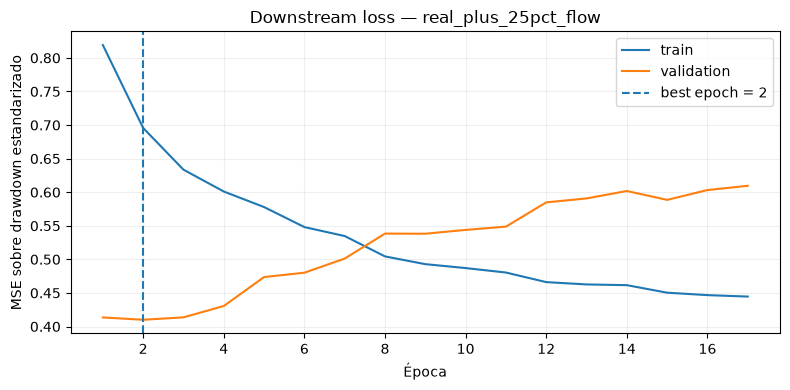

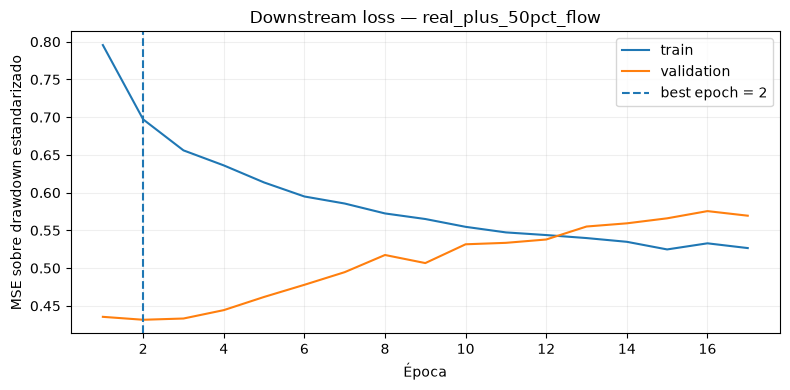

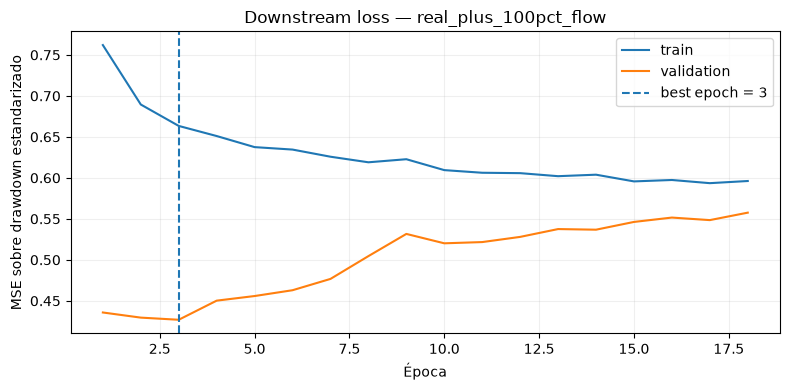

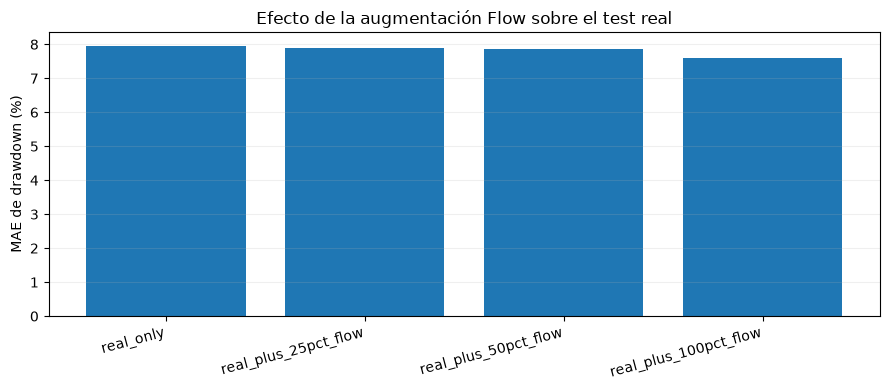

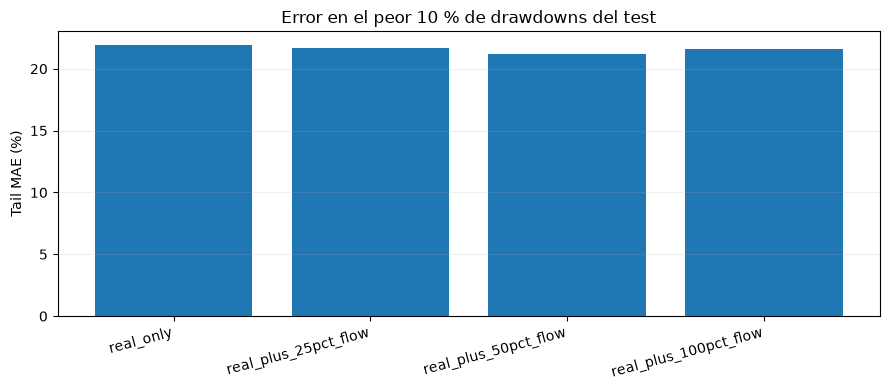

In [20]:
# Curvas de loss: una figura por mezcla para comprobar convergencia
# manteniendo la misma arquitectura downstream.

for label, history_ds in downstream_histories.items():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history_ds["epoch"], history_ds["train_mse_scaled"], label="train")
    ax.plot(history_ds["epoch"], history_ds["validation_mse_scaled"], label="validation")
    best_epoch_plot = int(
        downstream_comparison.loc[
            downstream_comparison["dataset"].eq(label), "best_epoch"
        ].iloc[0]
    )
    ax.axvline(best_epoch_plot, linestyle="--", label=f"best epoch = {best_epoch_plot}")
    ax.set_title(f"Downstream loss — {label}")
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE sobre drawdown estandarizado")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Comparación principal: MAE en test real
fig, ax = plt.subplots(figsize=(9, 4))
positions = np.arange(len(downstream_comparison))
ax.bar(positions, 100 * downstream_comparison["test_mae"])
ax.set_xticks(positions)
ax.set_xticklabels(downstream_comparison["dataset"], rotation=15, ha="right")
ax.set_ylabel("MAE de drawdown (%)")
ax.set_title("Efecto de la augmentación Flow sobre el test real")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# Comportamiento en la cola: peores 10 % de drawdowns reales
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(positions, 100 * downstream_comparison["test_tail_mae_worst_10pct"])
ax.set_xticks(positions)
ax.set_xticklabels(downstream_comparison["dataset"], rotation=15, ha="right")
ax.set_ylabel("Tail MAE (%)")
ax.set_title("Error en el peor 10 % de drawdowns del test")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 8.1 Interpretación

Esta comparación responde directamente a la pregunta del taller: **¿qué ocurre cuando aumentamos el train con datos generados por el Flow manteniendo fijo el modelo predictivo?**

La comparación válida es la tabla ejecutada arriba. Deben destacarse tres ideas:

1. El test y la validación permanecen **100 % reales**, por lo que una mejora no puede explicarse por evaluar sobre sintéticos.
2. La arquitectura, inicialización, optimizador y escalado del target son iguales; la variable experimental es únicamente la proporción de datos sintéticos en train.
3. Una mejora de MAE con augmentación puede interpretarse como evidencia de utilidad downstream del generador, pero debe leerse junto al `R²` y al error de cola. Si el `R²` continúa siendo negativo, el resultado correcto es hablar de **mejora relativa de error bajo una arquitectura fija**, no de un predictor de drawdown excelente.

## 9. Guardado reproducible


In [21]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
downstream_comparison.to_csv(OUTPUT_DIR / "downstream_comparison.csv", index=False)
for label, history_ds in downstream_histories.items():
    history_ds.to_csv(OUTPUT_DIR / f"downstream_history_{label}.csv", index=False)

checkpoint = {
    "config": asdict(CONFIG),
    "model_state_dict": model.state_dict(),
    "best_epoch_1_based": best_epoch + 1,
    "best_validation_nll_per_dimension": best_validation,
    "train_history": train_history,
    "validation_history": validation_history,
}
torch.save(checkpoint, OUTPUT_DIR / "conditional_realnvp_best.pt")

np.savez_compressed(
    OUTPUT_DIR / "test_scenarios.npz",
    generated_normalized=generated_normalized_flat,
    generated_conditional_returns=generated_conditional_returns,
    generated_returns=generated_returns,
    real_normalized=x_test,
    real_returns=reference_returns,
    conditions=c_test,
    assets=assets,
)

metadata = {
    "selected_config": asdict(CONFIG),
    "selection": {
        "metric": "validation_nll_per_dimension",
        "best_epoch_1_based": best_epoch + 1,
        "best_validation_nll_per_dimension": best_validation,
        "test_used_for_selection": False,
    },
    "train_samples": len(x_train),
    "validation_samples": len(x_validation),
    "test_samples": len(x_test),
    "scenarios_per_condition": SCENARIOS_PER_CONDITION,
    "evaluation": {
        "marginal": marginal_report.to_dict(),
        "temporal": temporal_report.to_dict(),
        "cross_asset": cross_asset_report.to_dict(),
        "trajectory": trajectory_report.to_dict(),
        "risk": risk_report.to_dict(),
        "diversity_and_memorization": diversity_report.to_dict(),
    },
    "downstream": {
        "task": "predict_30d_maximum_drawdown_magnitude_60_40_btc_eth",
        "augmentation_ratios": list(AUGMENTATION_RATIOS),
        "configuration": asdict(DOWNSTREAM_CONFIG),
        "comparison": downstream_comparison.to_dict(orient="records"),
        "validation_and_test": "real_only",
    },
    "non_overlapping_sensitivity": {
        "anchors": len(non_overlapping_ids),
        "marginal": non_overlapping_marginal_report.to_dict(),
        "trajectory": non_overlapping_trajectory_report.to_dict(),
    },
}
(OUTPUT_DIR / "metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print("Artefactos guardados en:", OUTPUT_DIR.relative_to(ROOT))


Artefactos guardados en: outputs/normalizing_flow_best


## Conclusión

Este notebook deja el Normalizing Flow con la misma organización que los otros modelos del repositorio: carga del dataset común, configuración explícita, implementación del modelo, entrenamiento, generación, evaluación común, experimento downstream y guardado reproducible.

El Conditional RealNVP aprende una transformación invertible condicionada por 14 variables de mercado. Esa invertibilidad permite generar trayectorias BTC–ETH nuevas a partir de ruido gaussiano y calcular una densidad exacta bajo el modelo. La evaluación común separa fidelidad marginal, dependencia temporal y cruzada, propiedades de trayectoria, riesgo y diversidad/memorización.

La sección downstream añade el segundo objetivo del taller: comprobar si los sintéticos aportan utilidad al entrenar otro modelo. Se comparan cuatro versiones de **la misma MLP** —real-only, +25 %, +50 % y +100 % de sintéticos Flow— manteniendo validación y test exclusivamente reales. La interpretación final debe apoyarse en la tabla y las curvas ejecutadas: interesa tanto la variación del MAE como el `R²` y el error en los peores drawdowns.